# Orszag-Tang 3D with spectral z (`z_spectral=True`)

A variant of `orzag-tang-3d.ipynb` that runs the same initial condition twice: once with the
default 4th-order **finite-difference** z, once with `z_spectral=True`, where the z axis of
`state.fields` is `kz` and the parallel (Alfven) operator is applied **exactly** by the linear
propagator instead of being a right-hand-side term.

What the mode changes (plans/GDI_PLAN.md P2):

* `grids.fft`/`grids.ifft` switch from `rfft2` to `rfftn`/`irfftn` over (z, x, y). Field shapes
  are unchanged, `(nfields, nz, nkx, nky)`; axis 1 just means `kz` now.
* The dealias mask gains a 2/3 cut in `kz` (the brackets are pointwise in z, so products alias
  in `kz` too).
* `rmhd.LinearTerm` and the z halo exchange are skipped entirely; the parallel physics lives in
  `linear_matrix` as the off-diagonal `+-i*kz` coupling of a 2x2 operator, propagated exactly.
* `set_timestep` therefore drops the `1/dz` (Alfven) and `z_diss` entries: **dt is set by the
  perpendicular advection alone.**
* Every energy-like reduction picks up the Parseval factor of `nz` for the unnormalized z-FFT,
  so `diagnostics.energy`, `perpspec`, `parspec` and the forcing power stay directly comparable
  between the two modes.

Constraints: `z_spectral=True` requires `dims=3` and a **single process** (the z-FFT needs the
whole z domain), and is rejected with `comm_backend="jax"`. It is recorded in `params.json`, and
snapshots are **not** cross-mode compatible - the `params.save` comparison is the guard.

In [1]:
%matplotlib inline
import os

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import taranis as jr
import taranis.snapshot_io as sn
from taranis import diagnostics as dg
from taranis.grids import ifft

# modest resolution: this notebook runs both modes end to end on a laptop CPU
nx = ny = nz = 32
Lx = Ly = Lz = 2.0*np.pi
cfl_safety = 0.5
t_snap, t_end = 0.5, 4.0
visc = res = 1e-5
hyper = 3

def make_params(z_spectral):
    return jr.Parameters(nx=nx, ny=ny, nz=nz, Lx=Lx, Ly=Ly, Lz=Lz, dims=3,
                         eqpars={"diss": (visc, res), "hyper": hyper},
                         cfl_safety=cfl_safety, z_spectral=z_spectral)

def ot_init(x, y, z):
    # the orzag-tang-3d.ipynb initial condition, unchanged
    phi = (jnp.cos(x + 1.4) + jnp.cos(y + 0.5))*jnp.sin(z)
    psi = (jnp.cos(2.0*x + 2.3) + jnp.cos(y + 4.1))*jnp.cos(z)
    return jnp.stack([phi, psi], axis=0)

runs = {"finite-difference z": ("data/ot3d_zspec_fd", False),
        "spectral z": ("data/ot3d_zspec_sp", True)}
params = {}

for label, (path, z_spectral) in runs.items():
    p = make_params(z_spectral)
    params[label] = p
    if sn.get_saved_steps(path):
        print(f"{label}: reusing existing snapshots in {path}")
        continue
    os.makedirs(path, exist_ok=True)
    p.save(path)                      # records z_spectral: a cross-mode reload is a hard error
    mngr = jr.snapshot_manager_setup(p, snap_path=path, nsnap=100)
    state = jr.initialize(ot_init, p)
    jr.simulate_scan(state, jr.setup_kgrids(p), p, 10, t_snap=t_snap, t_end=t_end,
                     mngr=mngr, save=True, print_every=100)
    mngr.wait_until_finished()
    mngr.close()

jax is using 32bit precision.


Saving initial state as snapshot 0 at t = 0.0


Saving snapshot as snapshot 1 at t = 0.8308137655258179
Saving snapshot as snapshot 2 at t = 1.513217568397522
Saving snapshot as snapshot 3 at t = 2.288173198699951


Saving snapshot as snapshot 4 at t = 3.096294641494751
Saving snapshot as snapshot 5 at t = 3.8295698165893555
Saving final state as snapshot 6 at t = 4.158102989196777
Ending simulation at t = 4.158103. It took 1.130192751006689s


Saving initial state as snapshot 0 at t = 0.0


Saving snapshot as snapshot 1 at t = 0.8311589360237122
Saving snapshot as snapshot 2 at t = 1.5177075862884521


Saving snapshot as snapshot 3 at t = 2.2949955463409424
Saving snapshot as snapshot 4 at t = 3.08899188041687


Saving snapshot as snapshot 5 at t = 3.8179848194122314
Saving final state as snapshot 6 at t = 4.148566722869873
Ending simulation at t = 4.1485667. It took 1.7043596250005066s


## The two modes agree

Energies from the saved snapshots. The finite-difference run differs from the spectral one only
through the 4th-order z stencil's dispersion error (`k_eff != k`, see docs/numerics.md), which is
`O(dz^4)`: `tests/test_z_spectral.py::test_fd_z_converges_to_spectral_at_fourth_order` measures
that order directly (3.88 at nz = 16/32/64). At nz = 32 the energies track each other to
well under a percent (measured below).

Two caveats before reading the pointwise field comparison further down: the adaptive timesteps
differ slightly between the runs, so the two snapshot sequences land on slightly different times
(`simulate_scan` overshoots `t_snap`/`t_end` by up to a step, and the states are separated by an
advection offset of that size), and Orszag-Tang at these parameters is chaotic - a small initial
difference grows. The integrated energies are the fair comparison; the field difference plot is
structure, not an error norm.

finite-difference z: 7 snapshots, t up to 4.158
spectral z: 7 snapshots, t up to 4.149


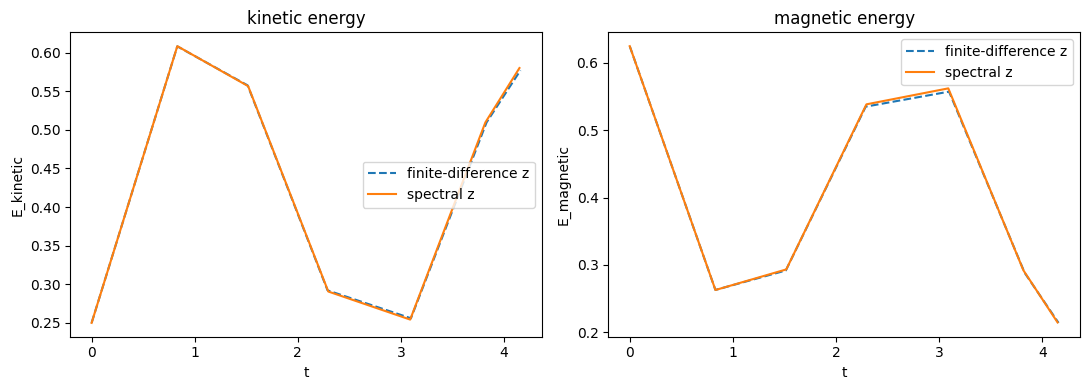

max relative kinetic-energy difference between the two modes: 6.673e-03


In [2]:
series = {}
for label, (path, _) in runs.items():
    p = params[label]
    kgrid = jr.setup_kgrids(p)
    ts, ekin, emag = [], [], []
    for isnap in sn.get_saved_steps(path):
        snap = sn.load_snapshot(isnap, path, p)
        E = dg.energy(snap, kgrid, p)
        ts.append(float(snap.t)); ekin.append(float(E[0])); emag.append(float(E[1]))
    series[label] = (np.array(ts), np.array(ekin), np.array(emag))
    print(f"{label}: {len(ts)} snapshots, t up to {ts[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for label, (ts, ekin, emag) in series.items():
    style = "-" if "spectral" in label else "--"
    ax[0].plot(ts, ekin, style, label=label)
    ax[1].plot(ts, emag, style, label=label)
for a, name in zip(ax, ("kinetic", "magnetic")):
    a.set_xlabel("t"); a.set_ylabel(f"E_{name}"); a.legend(); a.set_title(f"{name} energy")
plt.tight_layout(); plt.show()

fd, sp = series["finite-difference z"], series["spectral z"]
n = min(len(fd[0]), len(sp[0]))
rel = np.max(np.abs(fd[1][:n] - sp[1][:n])/np.abs(sp[1][:n]))
print(f"max relative kinetic-energy difference between the two modes: {rel:.3e}")

## Real-space structure

`grids.ifft(fields, params)` dispatches on the mode, so the same call returns real-space
`(z, x, y)` in both runs - `irfft2` for finite-difference z, `irfftn` for spectral z.

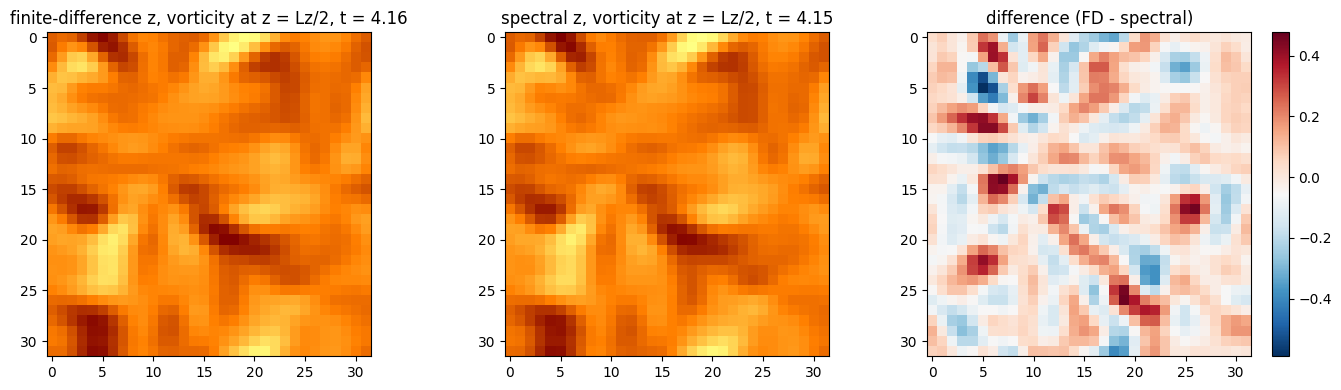

max |vorticity| = 7.905, max |FD - spectral| = 5.897e-01 (7.5% of the peak)
snapshot times: finite-difference z t=4.1581, spectral z t=4.1486  <- the two runs took different adaptive steps


In [3]:
snaps = {}
for label, (path, _) in runs.items():
    p = params[label]
    isnap = sn.get_saved_steps(path)[-1]
    snap = sn.load_snapshot(isnap, path, p)
    kgrid = jr.setup_kgrids(p)
    vort = np.asarray(ifft(-kgrid.ksq*snap.fields[0], p))   # real space (z, x, y)
    snaps[label] = (float(snap.t), vort)

vmax = float(np.max(np.abs(snaps["spectral z"][1])))
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, label in zip(ax, runs):
    t, vort = snaps[label]
    a.imshow(vort[nz//2], cmap="afmhot", vmin=-vmax, vmax=vmax)
    a.set_title(f"{label}, vorticity at z = Lz/2, t = {t:.2f}")
diff = snaps["finite-difference z"][1][nz//2] - snaps["spectral z"][1][nz//2]
im = ax[2].imshow(diff, cmap="RdBu_r")
ax[2].set_title("difference (FD - spectral)")
plt.colorbar(im, ax=ax[2]); plt.tight_layout(); plt.show()
print(f"max |vorticity| = {vmax:.3f}, max |FD - spectral| = {np.max(np.abs(diff)):.3e} "
      f"({100*np.max(np.abs(diff))/vmax:.1f}% of the peak)")
print("snapshot times: " + ", ".join(f"{k} t={v[0]:.4f}" for k, v in snaps.items())
      + "  <- the two runs took different adaptive steps")

## Spectra

Both spectra share the one normalization convention (`docs/numerics.md`), with the extra
`1/nz` that Parseval requires for the unnormalized z-FFT folded into `perp_reduce`, so the
numbers are directly comparable between the modes. `parspec` is a plain sum over `kz` in
spectral mode - no transform at all - and is single-process only either way.

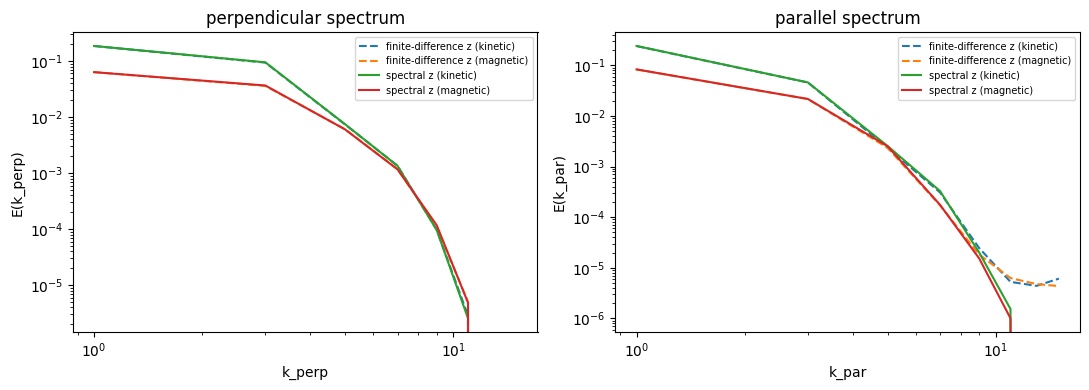

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for label, (path, _) in runs.items():
    p = params[label]
    kgrid = jr.setup_kgrids(p)
    snap = sn.load_snapshot(sn.get_saved_steps(path)[-1], path, p)
    kperp, ekin, emag = dg.perpspec(snap, kgrid, p)
    kpar, pkin, pmag = dg.parspec(snap, kgrid, p)
    style = "-" if "spectral" in label else "--"
    ax[0].loglog(kperp, ekin, style, label=f"{label} (kinetic)")
    ax[0].loglog(kperp, emag, style, label=f"{label} (magnetic)")
    ax[1].loglog(kpar, pkin, style, label=f"{label} (kinetic)")
    ax[1].loglog(kpar, pmag, style, label=f"{label} (magnetic)")
ax[0].set_xlabel("k_perp"); ax[0].set_ylabel("E(k_perp)"); ax[0].set_title("perpendicular spectrum")
ax[1].set_xlabel("k_par"); ax[1].set_ylabel("E(k_par)"); ax[1].set_title("parallel spectrum")
for a in ax: a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## The payoff: dt is set by the perpendicular CFL alone

The finite-difference timestep carries a `1/dz` Alfven-wave term (and a `z_diss` term), so it
falls as `1/nz` once the parallel grid is fine enough. The spectral timestep does not: the wave
is propagated exactly. Note the honest caveat visible below - at `nz ~ nx` with `O(1)`
Orszag-Tang amplitudes the perpendicular advection is what binds anyway, so the two agree; the
mode pays off for parallel-resolved (large `nz`) or weakly-nonlinear runs.

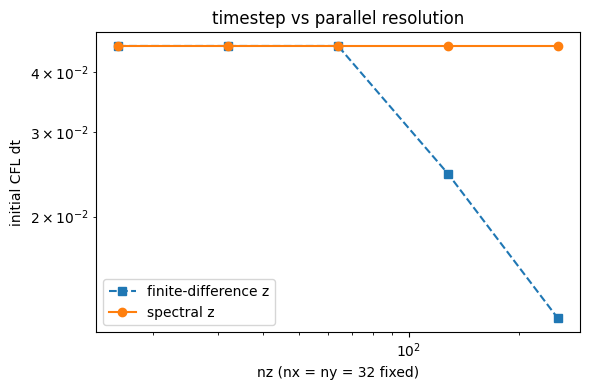

nz=  16   dt_FD=0.0453   dt_spectral=0.0453   speedup=1.00x
nz=  32   dt_FD=0.0453   dt_spectral=0.0453   speedup=1.00x
nz=  64   dt_FD=0.0453   dt_spectral=0.0453   speedup=1.00x
nz= 128   dt_FD=0.0245   dt_spectral=0.0453   speedup=1.84x
nz= 256   dt_FD=0.0123   dt_spectral=0.0453   speedup=3.69x


In [5]:
nz_scan = [16, 32, 64, 128, 256]
dts = {"finite-difference z": [], "spectral z": []}
from taranis.physics import rmhd
for nz_s in nz_scan:
    for label, z_spectral in (("finite-difference z", False), ("spectral z", True)):
        p = jr.Parameters(nx=nx, ny=ny, nz=nz_s, Lx=Lx, Ly=Ly, Lz=Lz, dims=3,
                          eqpars={"diss": (visc, res), "hyper": hyper},
                          cfl_safety=cfl_safety, z_spectral=z_spectral)
        kg = jr.setup_kgrids(p)
        st = jr.initialize(ot_init, p)
        dts[label].append(float(rmhd.set_timestep(rmhd.grad(st, kg, p), p)))

plt.figure(figsize=(6, 4))
for label, vals in dts.items():
    plt.loglog(nz_scan, vals, "o-" if "spectral" in label else "s--", label=label)
plt.xlabel("nz (nx = ny = 32 fixed)"); plt.ylabel("initial CFL dt"); plt.legend()
plt.title("timestep vs parallel resolution"); plt.tight_layout(); plt.show()
for nz_s, a, b in zip(nz_scan, dts["finite-difference z"], dts["spectral z"]):
    print(f"nz={nz_s:4d}   dt_FD={a:.4f}   dt_spectral={b:.4f}   speedup={b/a:.2f}x")

## Cross-mode snapshots are refused

`params.save` compares the recorded parameters, and `z_spectral` is one of them: pointing a
run of the other mode at an existing directory is a hard error rather than a silently wrong
restart (the field arrays have the same shape in both modes, so nothing else would catch it).

In [6]:
try:
    make_params(False).save("data/ot3d_zspec_sp")
except ValueError as e:
    print("refused, as it should be:\n ", str(e)[:300])

refused, as it should be:
  data/ot3d_zspec_sp/params.json already records different parameters (saved, current): {'z_spectral': (True, False)}. If the change is intended, delete params.json and re-save; to reuse the recorded values, Parameters.from_snapshot(...) and pass overrides explicitly.
